In [ ]:
import numpy as np
import pandas as pd
from scipy.io import loadmat

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns

# Load Data

In [2]:
dataPath = 'C:/Users/neubrand/Documents/Data2Dynamics/RealisticBenchmarkModels/analysisScripts/mergeResultsTables'
merged_file = dataPath + "/allMergedResults_V2_2_py.mat"

# Load the MATLAB file
mat_data = loadmat(merged_file)
S = mat_data["S"]
n_rows = S.shape[0]

# Parse MATLAB struct array into Python dicts
data = []
for i in range(n_rows):
    row_struct = S[i, 0]
    row = {}
    for field in S.dtype.names:
        value = row_struct[field]
        if isinstance(value, np.ndarray):
            if value.shape == (1, 1):  # scalar
                value = value[0, 0]
            elif value.dtype.kind in {"U", "S"} and value.shape[0] == 1:
                value = ''.join(value[0])
            elif value.dtype.char == "S":  # bytes from MATLAB char
                try:
                    value = b''.join(value.flat).decode("utf-8")
                except Exception:
                    value = str(value)
        row[field] = value
    data.append(row)

# Convert to DataFrame
df = pd.DataFrame(data)

print(df.columns)
print(df[["projectName", "templateName"]].head())


Index(['projectName', 'templateName', 'qTemplate', 'nParams', 'nParamsDyn',
       'nParamsInit', 'nParamsErr', 'nParamsFit', 'nStates', 'nInputs',
       'nConds', 'nExp', 'nTC', 'nDR', 'nDataPoints', 'nObsSets',
       'designSparsity', 'pLabel', 'qFit', 'qLog10', 'qDynamic', 'qError',
       'qInitial', 'qIdent', 'nNonIdent', 'ratioIdentAll', 'ratioIdentDyn',
       'ratioIdentErr', 'ratioIdentInit', 'medTime', 'meanTime',
       'medUniqueTime', 'meanUniqueTime', 'timeUnit', 'medErrorExp',
       'meanErrorExp', 'medLog10ErrExp', 'meanLog10ErrExp', 'medErrorSimu',
       'meanErrorSimu', 'medLog10ErrSimu', 'meanLog10ErrSimu',
       'minLog10HessEigen', 'qSloppy', 'log10HessEigen', 'hessEigenRaw',
       'chi2_list', 'chi2_sorted', 'iSort', 'levelLink', 'threshold', 'nLHS',
       'nSuccess', 'nLevels', 'nLevelsRepeated', 'levelVals',
       'levelPopulation', 'totalPopulationRepeated', 'lowestLevelPopulation',
       'lowestLevelVal', 'fitTimes', 'totalFitTime', 'medianFitTime',
 

# Style settings

In [3]:
fontsize = 6
ax_labelsize = 5

plt.rcParams.update({
    'font.size': fontsize,
    'text.usetex': True,
    'font.family': 'serif',
    'axes.labelsize': fontsize,
    'axes.titlesize': fontsize,
    'legend.fontsize': fontsize,
    'xtick.labelsize': ax_labelsize,
    'ytick.labelsize': ax_labelsize,
    'lines.markersize': 4
})

single_width_mm = 86 # in mm
double_width_mm = 178 # in mm
fig_width_mm = double_width_mm

mm2in = 1 / 25.4

In [4]:
## For template-resolved plotting

# Get unique templates
templateNames = df["templateName"].unique()
nTemplates = len(templateNames)

markerDict = {t: 'o' for t in templateNames}

tab20_colors = plt.cm.get_cmap("tab20", 20).colors
tab20b_colors = plt.cm.get_cmap("tab20b", 20).colors
extra_colors = [tab20b_colors[0], tab20b_colors[10]]
colors_22 = np.vstack([tab20_colors, extra_colors])
colorDict = {}
colorDict = {t: colors_22[i] for i, t in enumerate(templateNames)}

# switch colors of Swameye and Weber
colorDict["Swameye"], colorDict["Weber"] = colorDict["Weber"], colorDict["Swameye"]

# marker sizes
template_marker_size = 10
template_lw = 0.5

synthetic_marker_size = 3

# edges etc.
template_edge_color = "black"
synthetic_alpha = 0.1

C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\1017168264.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20_colors = plt.cm.get_cmap("tab20", 20).colors
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\1017168264.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20b_colors = plt.cm.get_cmap("tab20b", 20).colors


In [5]:
## For boxplots

flierprops = {"marker": "x", "markersize": 3}
bp_linewidth = 0.75
bp_linecolor = "black"

# Summary Statistics

In [6]:
def boxplot_stats(data, whis=1.5):
    """
    Compute boxplot statistics for a dataset.

    Parameters
    ----------
    data : array-like
        Input data (1D list, numpy array, or pandas Series).
    whis : float, optional (default=1.5)
        The whisker length (as in matplotlib’s boxplot: 
        whiskers extend to the most extreme data points within
        `whis * IQR` of the first/third quartile).

    Returns
    -------
    stats : dict
        Dictionary with:
        - 'median'
        - 'q1' (25th percentile)
        - 'q3' (75th percentile)
        - 'iqr'
        - 'lower_whisker'
        - 'upper_whisker'
        - 'fliers' (outliers beyond whiskers)
    """
    data = np.asarray(data)
    data = data[~np.isnan(data)]  # remove NaNs

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    median = np.median(data)
    iqr = q3 - q1

    # define whisker boundaries
    lower_bound = q1 - whis * iqr
    upper_bound = q3 + whis * iqr

    # actual whisker positions: most extreme points within bounds
    lower_whisker = np.min(data[data >= lower_bound]) if np.any(data >= lower_bound) else q1
    upper_whisker = np.max(data[data <= upper_bound]) if np.any(data <= upper_bound) else q3

    # outliers
    fliers = data[(data < lower_whisker) | (data > upper_whisker)]

    # min and max values
    min_val = np.min(data) if data.size > 0 else np.nan
    max_val = np.max(data) if data.size > 0 else np.nan

    return {
        'median': median,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_whisker': lower_whisker,
        'upper_whisker': upper_whisker,
        'fliers': fliers,
        'min': min_val,
        'max': max_val
    }


nObsSets: lims=8.00e-01, 3.12e+01, min=1.00e+00, max=2.50e+01
nParamsFit: lims=5.60e+00, 8.44e+02, min=7.00e+00, max=6.75e+02
nDataPoints: lims=4.80e+00, 3.58e+03, min=6.00e+00, max=2.86e+03
medErrorExp: lims=9.10e-03, 3.24e+00, min=1.14e-02, max=2.59e+00
medTime: lims=6.67e-03, 3.44e+03, min=8.33e-03, max=2.75e+03


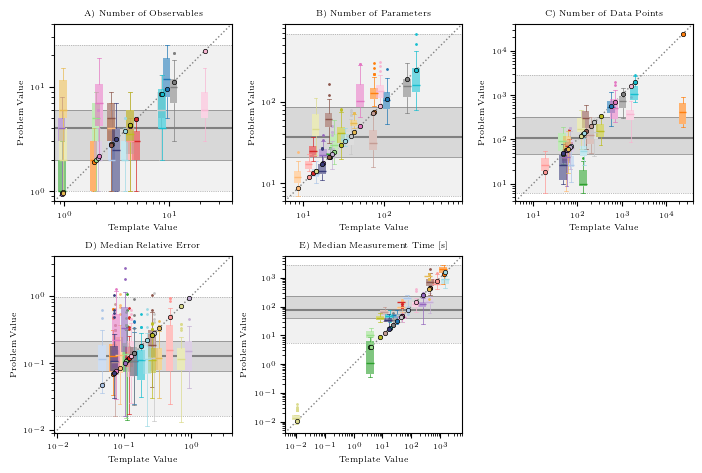

In [7]:
# flag for some visual adjustments
bp_background = True
add_jitter = True

# Correlation plots: For each variable, plot template value (x) vs 50 synthetic values (y)
variables = ['nObsSets', 'nParamsFit', 'nDataPoints', 'medErrorExp', 'medTime']
titles = ['A) Number of Observables', 'B) Number of Parameters',
          'C) Number of Data Points', 'D) Median Relative Error',
          'E) Median Measurement Time [s]']
templates = df[df["qTemplate"] == 1]
synthetics = df[df["qTemplate"] == 0]

# calculate limits for each variable based on synthetic values
boundary_factor = 0.8

lims = {}
for var in variables:
    syn_vals = synthetics[var].dropna()
    syn_vals = synthetics[var][np.isfinite(syn_vals)]
    vmin = syn_vals.min()
    vmax = syn_vals.max()
    if vmin <= 0:
        vmin = syn_vals[syn_vals > 0].min() * 0.5
    if vmax <= 0:
        vmax = 10
    lims[var] = (vmin * boundary_factor, vmax * (1 / boundary_factor))
    if lims[var][0] == lims[var][1]:
        lims[var] = (lims[var][0] * boundary_factor, lims[var][1] * (1 / boundary_factor))
    print(f"{var}: lims={lims[var][0]:.2e}, {lims[var][1]:.2e}, min={vmin:.2e}, max={vmax:.2e}")

# modify limits to better show data range

lims = {
    'nObsSets': (8e-1, 4e1),
    'nParamsFit': (6e0, 9e2),
    'nDataPoints': (4e0, 4e4),
    'medErrorExp': (9e-3, 4e0),
    'medTime': (4e-3, 6e3)
}

fig_height_mm = 120 # in mm
fig, axes = plt.subplots(2, 3, figsize=(fig_width_mm * mm2in, fig_height_mm * mm2in),
                         sharey=False,
                         )
axes = axes.flatten()

if len(variables) == 1:
    axes = [axes]

for i, var in enumerate(variables):
    ax = axes[i]
    all_template_vals = []
    all_syn_vals = []

    for template_name in templateNames:
        template_val = templates.loc[templates["templateName"] == template_name, var].values
        syn_vals = synthetics.loc[synthetics["templateName"] == template_name, var].dropna().values

        if len(template_val) == 0 or len(syn_vals) == 0:
            continue

        # add jitter to template x-position
        if add_jitter:
            jitter_strength = 0.02 * np.log10(lims[var][1] / lims[var][0])
        else:
            jitter_strength = 0.0
        temp_x_val = template_val[0] * 10**np.random.uniform(-jitter_strength, jitter_strength)

        # define boxplot width
        # constant width in log10 space (e.g., 0.1 decades)
        bp_width = 0.1 * temp_x_val * np.log10(lims[var][1] / lims[var][0])

        # --- Boxplot for synthetic values ---
        bp = ax.boxplot(
            syn_vals,
            positions=[temp_x_val],
            widths=bp_width,  # relative box width (adjust as needed)
            patch_artist=True,
            boxprops=dict(facecolor=colorDict[template_name], alpha=0.6, color='none'),
            whiskerprops=dict(color=colorDict[template_name], alpha=1, lw=0.5),
            capprops=dict(color=colorDict[template_name], alpha=1, lw=0.5),
            medianprops=dict(color=colorDict[template_name], lw=1),
            flierprops=dict(marker='.',
                            markerfacecolor=colorDict[template_name],
                            markeredgecolor=colorDict[template_name],
                            alpha=1, markersize=2)
        )

        if bp_background:
            # add a white boxplot in the background to avoid color change due to background
            bp = ax.boxplot(
                syn_vals,
                positions=[temp_x_val],
                widths=bp_width,  # relative box width (adjust as needed)
                patch_artist=True,
                boxprops=dict(facecolor='white', alpha=1, color='none'),
                whiskerprops=dict(color='white', alpha=1, lw=0),
                capprops=dict(color='white', alpha=0.5, lw=0),
                medianprops=dict(color='white', lw=0),
                flierprops=dict(marker='.', markerfacecolor='white', alpha=0, markersize=2),
                zorder=-3
            )

        # --- Highlight template point ---
        ax.scatter(temp_x_val, temp_x_val,
                   color=colorDict[template_name],
                   marker=markerDict[template_name],
                   edgecolor=template_edge_color,
                   lw=template_lw,
                   s=template_marker_size,
                   zorder=3)

        # Collect for correlation
        all_template_vals.extend([template_val[0]] * len(syn_vals))
        all_syn_vals.extend(syn_vals)

    # Identity line
    ax.plot([lims[var][0], lims[var][1]], [lims[var][0], lims[var][1]],
            color='gray', linestyle=':', lw=1, zorder=-4)

    # --- Compute stats for annotation ---
    all_template_vals = np.array(all_template_vals)
    all_syn_vals = np.array(all_syn_vals)
    corr_coef = np.corrcoef(np.log10(all_template_vals), np.log10(all_syn_vals))[0, 1]

    temp_bp_stats = boxplot_stats(np.log10(templates[var]), whis=1.5)
    syn_bp_stats = boxplot_stats(np.log10(synthetics[var]), whis=1.5)

    synth_color = "gray"
    synth_color_fill = "lightgray"

    quartile_alpha = 0.8
    quartile_lw = 0.5
    whisker_alpha = 0.3
    whisker_lw = 0.5
    whisker_ls = ':'

    # add boxplot stats visuailzation for synthetics in the background
    if bp_background:
        ax.axhline(10**syn_bp_stats['median'],
                color=synth_color,
                linestyle='-', lw=1.5,
                zorder=-4)
        ax.axhline(10**syn_bp_stats['q1'], color=synth_color, linestyle='-', lw=quartile_lw, zorder=-5)
        ax.axhline(10**syn_bp_stats['q3'], color=synth_color, linestyle='-', lw=quartile_lw, zorder=-5)
        ax.axhline(10**syn_bp_stats['lower_whisker'], color=synth_color, linestyle=whisker_ls, lw=whisker_lw, zorder=-5)
        ax.axhline(10**syn_bp_stats['upper_whisker'], color=synth_color, linestyle=whisker_ls, lw=whisker_lw, zorder=-5)
        ax.fill_between([lims[var][0], lims[var][1]],
                        10**syn_bp_stats['q1'], 10**syn_bp_stats['q3'],
                        color=synth_color_fill, alpha=quartile_alpha,
                        lw=0,
                        zorder=-6)
        ax.fill_between([lims[var][0], lims[var][1]],
                        10**syn_bp_stats['lower_whisker'], 10**syn_bp_stats['upper_whisker'],
                        color=synth_color_fill, alpha=whisker_alpha,
                        lw=0,
                        zorder=-6)

    # Axes setup
    ax.set_xlim(lims[var])
    ax.set_ylim(lims[var])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Template Value")
    ax.set_ylabel("Problem Value")
    ax.set_title(titles[i])
    ax.set_aspect('equal')

# --- Add legend to your legend axis ---
axes[5].axis("off")



plt.tight_layout()
plt.savefig("SummaryStats_V3.png", dpi=600, bbox_inches='tight')
plt.savefig("SummaryStats_V3.pdf", bbox_inches='tight')
# plt.show()

### Related calculations

In [8]:
# Calculate percentage deviation between medians for template and synthetic for each variable
pct_deviation = {}
for var in variables:
    median_template = templates[var].median()
    median_synthetic = synthetics[var].median()
    if median_template != 0:
        pct_deviation[var] = 100 * (median_synthetic - median_template) / median_template
    else:
        pct_deviation[var] = np.nan  # Avoid division by zero

for var in variables:
    print(f"{var}: Median Template = {templates[var].median():.3g}, "
          f"Median Synthetic = {synthetics[var].median():.3g}, "
          f"Deviation = {pct_deviation[var]:.2f}%")

nObsSets: Median Template = 3, Median Synthetic = 4, Deviation = 33.33%
nParamsFit: Median Template = 26.5, Median Synthetic = 37, Deviation = 39.62%
nDataPoints: Median Template = 135, Median Synthetic = 106, Deviation = -21.48%
medErrorExp: Median Template = 0.122, Median Synthetic = 0.126, Deviation = 3.04%
medTime: Median Template = 52.5, Median Synthetic = 73.8, Deviation = 40.48%


In [9]:
# Calculate percentage deviation between medians for template and synthetic for each variable
pct_deviation = {}
for var in variables:
    mean_template = templates[var].mean()
    mean_synthetic = synthetics[var].mean()
    if mean_template != 0:
        pct_deviation[var] = 100 * (mean_synthetic - mean_template) / mean_template
    else:
        pct_deviation[var] = np.nan  # Avoid division by zero

for var in variables:
    print(f"{var}: Mean Template = {templates[var].mean():.3g}, "
          f"Mean Synthetic = {synthetics[var].mean():.3g}, "
          f"Deviation = {pct_deviation[var]:.2f}%")

nObsSets: Mean Template = 4.68, Mean Synthetic = 5, Deviation = 6.72%
nParamsFit: Mean Template = 54, Mean Synthetic = 64.1, Deviation = 18.82%
nDataPoints: Mean Template = 1.6e+03, Mean Synthetic = 257, Deviation = -83.92%
medErrorExp: Mean Template = 0.215, Mean Synthetic = 0.184, Deviation = -14.41%
medTime: Mean Template = 282, Mean Synthetic = 301, Deviation = 6.77%


## Identifiability

In [10]:
# Calculate ratio of non-dynamic identifiable parameters: sum(qFit & ~qDyn & qIdent) / sum(qFit&~qDyn)
def nDynFit(row):
    qFit = np.array(row["qFit"]).astype(bool)
    qDyn = np.array(row["qDynamic"]).astype(bool)
    return (qFit & qDyn).sum()


def ratio_nondyn_ident(row):
    qFit = np.array(row["qFit"]).astype(bool)
    qDyn = np.array(row["qDynamic"]).astype(bool)
    qIdent = np.array(row["qIdent"]).astype(bool)
    nonDyn = qFit & ~qDyn
    ident = nonDyn & qIdent
    if nonDyn.sum() == 0:
        return np.nan
    return ident.sum() / nonDyn.sum()

df["ratioNonDynIdent"] = df.apply(ratio_nondyn_ident, axis=1)
df["nParamsDynFit"] = df.apply(nDynFit, axis=1)

In [11]:
# Interquartile range (IQR) for ratioNonDynIdent
qTemp = 1
var = 'ratioIdentDyn'
iqr = df[df['qTemplate'] == qTemp][var].quantile(0.75) - df[df['qTemplate'] == qTemp][var].quantile(0.25)
print("Interquartile range (IQR):", iqr)

df[df['qTemplate'] == qTemp][var].describe()

Interquartile range (IQR): 0.2857142857142857


count    21.000000
mean      0.869447
std       0.160659
min       0.428571
25%       0.714286
50%       0.930233
75%       1.000000
max       1.000000
Name: ratioIdentDyn, dtype: float64

In [12]:
df['ratioNonDynIdent'].describe()

count    1012.000000
mean        0.930337
std         0.138552
min         0.000000
25%         0.909091
50%         1.000000
75%         1.000000
max         1.000000
Name: ratioNonDynIdent, dtype: float64

<>:59: SyntaxWarning: invalid escape sequence '\%'
<>:59: SyntaxWarning: invalid escape sequence '\%'
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\1393911096.py:59: SyntaxWarning: invalid escape sequence '\%'
  axes[0].set_ylabel("Identifiability Ratio [\%]")


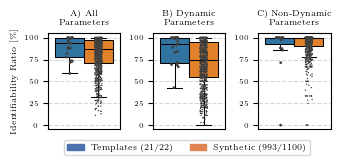

In [13]:
vars = ['ratioIdentAll', 'ratioIdentDyn', 'ratioNonDynIdent']
labels = ['A) All\nParameters', 'B) Dynamic\nParameters', 'C) Non-Dynamic\nParameters']

fig, axes = plt.subplots(1, 3, figsize=(single_width_mm*mm2in, 35*mm2in))

for var, ax in zip(vars, axes):

    records = []
    for _, row in df.iterrows():
        if pd.isna(row[var]):
            continue
        if row["qTemplate"] == 1:
            records.append({"group": "all templates", "variable": var, "value": row[var]})
        else:
            records.append({"group": "all synthetic", "variable": var, "value": row[var]})
    plot_df = pd.DataFrame(records)

    plot_df = plot_df * 100 # scale to percentage

    # count number of valid entries in each group
    if ax == axes[0]:
        [nSynth, nTemp] = plot_df['group'].value_counts()


    # First draw boxplot without fliers
    flierprops_temp = {"marker": "x", "markersize": 0}
    sns.boxplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                linewidth=bp_linewidth, linecolor=bp_linecolor,
                flierprops=flierprops_temp
                )

    # Draw stripplots on top of boxplot
    scatter_color = '0.25'
    sns.stripplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                size=2, dodge=True,
                palette=[scatter_color, "none"]
                )
    sns.stripplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                size=1, dodge=True,
                palette=["none", scatter_color]
                )
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, linestyle="--", alpha=0.5)

    ax.set_ylim(-5, 105)
    
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_xticks([])
    ax.set_title(labels[vars.index(var)])

axes[0].set_ylabel("Identifiability Ratio [\%]")

# create legend for the entire figure:
handles = [
        mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)", ls='-'),
        mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)", linewidth=1)
    ]
by_label = {h.get_label(): h for h in handles}
leg = fig.legend(by_label.values(), by_label.keys(),
                 loc="lower center", ncol=2,
                 bbox_to_anchor=(0.55, -0.15)
                )

plt.tight_layout()
plt.savefig("StripBoxPlots_Identifiability.png", dpi=600, bbox_inches='tight', bbox_extra_artists=(leg,))
plt.savefig("StripBoxPlots_Identifiability.pdf", bbox_inches='tight', bbox_extra_artists=(leg,))
plt.show()

In [14]:
synthetics = df[df["qTemplate"] == 0]
templates = df[df["qTemplate"] == 1]
vars = ['ratioIdentAll', 'ratioIdentDyn', 'ratioNonDynIdent']
for var in vars:
    print(f"Statistics for {var} (synthetics):")
    display(boxplot_stats(synthetics[var].dropna()))
    print(f"Statistics for {var} (templates):")
    display(boxplot_stats(templates[var].dropna()))
    print("\n")
    

Statistics for ratioIdentAll (synthetics):


{'median': 0.8666666666666667,
 'q1': 0.7083333333333334,
 'q3': 0.9679144385026738,
 'iqr': 0.2595811051693404,
 'lower_whisker': 0.32,
 'upper_whisker': 1.0,
 'fliers': array([0.25      , 0.31818182, 0.3       , 0.17647059, 0.11111111,
        0.2173913 , 0.13043478, 0.21428571, 0.25      , 0.24137931,
        0.275     , 0.28125   , 0.28571429, 0.31372549, 0.28571429,
        0.25531915, 0.1875    , 0.15686275, 0.26415094, 0.28301887,
        0.26315789, 0.28070175, 0.31372549, 0.22      , 0.19148936,
        0.16666667, 0.28      , 0.15686275, 0.26530612]),
 'min': 0.1111111111111111,
 'max': 1.0}

Statistics for ratioIdentAll (templates):


{'median': 0.9333333333333333,
 'q1': 0.7777777777777778,
 'q3': 1.0,
 'iqr': 0.2222222222222222,
 'lower_whisker': 0.5909090909090909,
 'upper_whisker': 1.0,
 'fliers': array([], dtype=float64),
 'min': 0.5909090909090909,
 'max': 1.0}



Statistics for ratioIdentDyn (synthetics):


...

{'median': 0.9302325581395349,
 'q1': 0.7142857142857143,
 'q3': 1.0,
 'iqr': 0.2857142857142857,
 'lower_whisker': 0.42857142857142855,
 'upper_whisker': 1.0,
 'fliers': array([], dtype=float64),
 'min': 0.42857142857142855,
 'max': 1.0}



Statistics for ratioNonDynIdent (synthetics):


{'median': 1.0,
 'q1': 0.9090909090909091,
 'q3': 1.0,
 'iqr': 0.09090909090909094,
 'lower_whisker': 0.7731481481481481,
 'upper_whisker': 1.0,
 'fliers': array([0.75      , 0.66666667, 0.33333333, 0.77192982, 0.77192982,
        0.45614035, 0.64912281, 0.71428571, 0.75      , 0.33333333,
        0.5       , 0.75      , 0.66666667, 0.33333333, 0.57142857,
        0.5       , 0.5       , 0.66666667, 0.33333333, 0.66666667,
        0.        , 0.        , 0.33333333, 0.5       , 0.42857143,
        0.66666667, 0.33333333, 0.76666667, 0.76      , 0.        ,
        0.75675676, 0.33333333, 0.73170732, 0.7037037 , 0.73684211,
        0.66666667, 0.71428571, 0.72727273, 0.76923077, 0.73333333,
        0.63636364, 0.66666667, 0.58333333, 0.76470588, 0.66666667,
        0.75      , 0.61538462, 0.6875    , 0.72222222, 0.75      ,
        0.66666667, 0.5       , 0.57142857, 0.25      , 0.4       ,
        0.76470588, 0.76923077, 0.46666667, 0.74074074, 0.75      ,
        0.55555556, 0.75     

Statistics for ratioNonDynIdent (templates):


{'median': 1.0,
 'q1': 0.9283559577677225,
 'q3': 1.0,
 'iqr': 0.0716440422322775,
 'lower_whisker': 0.8571428571428571,
 'upper_whisker': 1.0,
 'fliers': array([0.        , 0.71428571]),
 'min': 0.0,
 'max': 1.0}

In [15]:
# Calculate medians for templates and synthetics for ratioIdentAll, ratioIdentDyn, ratioNonDynIdent
vars = ['ratioIdentAll', 'ratioIdentDyn', 'ratioNonDynIdent']
labels = ['All Parameters', 'Dynamic Parameters', 'Other Parameters']

for var, label in zip(vars, labels):
    median_template = df[df["qTemplate"] == 1][var].median()
    median_synthetic = df[df["qTemplate"] == 0][var].median()
    print(f"{label}: Median Template = {100*median_template:.2f}%, Median Synthetic = {100*median_synthetic:.2f}%")
print("")

# Calculate IQR (interquartile range) for templates and synthetics for each variable
for var, label in zip(vars, labels):
    q25_template = df[df["qTemplate"] == 1][var].quantile(0.25)
    q75_template = df[df["qTemplate"] == 1][var].quantile(0.75)
    q25_synthetic = df[df["qTemplate"] == 0][var].quantile(0.25)
    q75_synthetic = df[df["qTemplate"] == 0][var].quantile(0.75)
    print(f"{label}: Template IQR = [{100*q25_template:.2f}%, {100*q75_template:.2f}%], {100*(q75_template - q25_template):.2f}%; Synthetic IQR = [{100*q25_synthetic:.2f}%, {100*q75_synthetic:.2f}%], {100*(q75_synthetic - q25_synthetic):.2f}%]")

All Parameters: Median Template = 93.33%, Median Synthetic = 86.67%
Dynamic Parameters: Median Template = 93.02%, Median Synthetic = 75.00%
Other Parameters: Median Template = 100.00%, Median Synthetic = 100.00%

All Parameters: Template IQR = [77.78%, 100.00%], 22.22%; Synthetic IQR = [70.83%, 96.79%], 25.96%]
Dynamic Parameters: Template IQR = [71.43%, 100.00%], 28.57%; Synthetic IQR = [55.00%, 94.44%], 39.44%]
Other Parameters: Template IQR = [92.84%, 100.00%], 7.16%; Synthetic IQR = [90.91%, 100.00%], 9.09%]


# Multistart Analysis

In [16]:
df["exitflag"]

exitflag_counts = df["exitflag"].apply(lambda arr: pd.Series({
    "exitflag_0": np.sum(arr == 0),
    "exitflag_1": np.sum(arr == 1),
    "exitflag_2": np.sum(arr == 2),
    "exitflag_3": np.sum(arr == 3),
    "exitflag_4": np.sum(arr == 4),
    "exitflag_nan": np.sum(pd.isna(arr))
}))

# Only create new columns if they don't already exist
for col in ["exitflag_0", "exitflag_1", "exitflag_2", "exitflag_3", "exitflag_4", "exitflag_nan"]:
    if col not in df.columns:
        df[col] = exitflag_counts[col]

exit0_total = sum(df["exitflag_0"])
exit1_total = sum(df["exitflag_1"])
exit2_total = sum(df["exitflag_2"])
exit3_total = sum(df["exitflag_3"])
exit4_total = sum(df["exitflag_4"])
exitnan_total = sum(df["exitflag_nan"])

print(f"Exitflag counts: 0: {exit0_total}, 1: {exit1_total}, 2: {exit2_total}, 3: {exit3_total}, 4: {exit4_total}, nan: {exitnan_total}")


Exitflag counts: 0: 3095, 1: 0, 2: 85556, 3: 0, 4: 0, nan: 23549


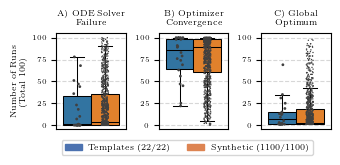

In [17]:
vars = ['exitflag_nan', 'exitflag_2', 'lowestLevelPopulation']
labels = ['A) ODE Solver\nFailure', 'B) Optimizer\nConvergence', 'C) Global\nOptimum']

fig, axes = plt.subplots(1, 3, figsize=(single_width_mm*mm2in, 35*mm2in))

for var, ax in zip(vars, axes):

    records = []
    for _, row in df.iterrows():
        if pd.isna(row[var]):
            continue
        if row["qTemplate"] == 1:
            records.append({"group": "all templates", "variable": var, "value": row[var]})
        else:
            records.append({"group": "all synthetic", "variable": var, "value": row[var]})
    plot_df = pd.DataFrame(records)

    # count number of valid entries in each group
    if ax == axes[0]:
        [nSynth, nTemp] = plot_df['group'].value_counts()


    # First draw boxplot without fliers
    flierprops_temp = {"marker": "x", "markersize": 0}
    sns.boxplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                linewidth=bp_linewidth, linecolor=bp_linecolor,
                flierprops=flierprops_temp
                )

    # Draw stripplots on top of boxplot
    scatter_color = '0.25'
    sns.stripplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                size=2, dodge=True,
                palette=[scatter_color, "none"]
                )
    sns.stripplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                size=1, dodge=True,
                palette=["none", scatter_color]
                )
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, linestyle="--", alpha=0.5)

    ax.set_ylim(-5, 105)
    
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_xticks([])
    ax.set_title(labels[vars.index(var)])

axes[0].set_ylabel("Number of Runs\n(Total 100)")

# create legend for the entire figure:
handles = [
        mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)", ls='-'),
        mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)", linewidth=1)
    ]
by_label = {h.get_label(): h for h in handles}
leg = fig.legend(by_label.values(), by_label.keys(),
                 loc="lower center", ncol=2,
                 bbox_to_anchor=(0.55, -0.15)
                )

plt.tight_layout()
plt.savefig("StripBoxPlots_Multistart.png", dpi=600, bbox_inches='tight', bbox_extra_artists=(leg,))
plt.savefig("StripBoxPlots_Multistart.pdf", bbox_inches='tight', bbox_extra_artists=(leg,))
plt.show()

In [18]:
synthetics = df[df["qTemplate"] == 0]
display(boxplot_stats(synthetics["exitflag_nan"].dropna()))
display(boxplot_stats(synthetics["exitflag_2"].dropna()))
display(boxplot_stats(synthetics["lowestLevelPopulation"].dropna()))

count_exitflag_nan_100 = (synthetics["exitflag_nan"] == 100).sum()
print("Number of synthetic problems with exitflag_nan == 100:", count_exitflag_nan_100)

{'median': 4.0,
 'q1': 0.0,
 'q3': 36.0,
 'iqr': 36.0,
 'lower_whisker': 0,
 'upper_whisker': 90,
 'fliers': array([100, 100,  95,  92,  95,  96,  96,  98,  99,  99,  92,  97,  98,
         95,  97,  97,  91,  92,  91,  92,  96,  93,  94,  93,  91]),
 'min': 0,
 'max': 100}

{'median': 89.0,
 'q1': 60.75,
 'q3': 98.0,
 'iqr': 37.25,
 'lower_whisker': 5,
 'upper_whisker': 100,
 'fliers': array([0, 0, 4, 4, 4, 2, 1, 1, 3, 2, 2, 2, 2, 4]),
 'min': 0,
 'max': 100}

{'median': 2.0,
 'q1': 1.0,
 'q3': 18.0,
 'iqr': 17.0,
 'lower_whisker': 1.0,
 'upper_whisker': 43.0,
 'fliers': array([46., 49., 51., 52., 66., 58., 52., 87., 45., 52., 79., 75., 45.,
        86., 74., 53., 74., 91., 93., 66., 84., 54., 93., 67., 69., 98.,
        54., 90., 97., 82., 80., 72., 89., 46., 79., 82., 90., 48., 86.,
        53., 91., 82., 79., 46., 47., 58., 79., 54., 47., 79., 70., 83.,
        45., 44., 51., 70., 62., 55., 90., 56., 51., 53., 89., 46., 60.,
        46., 71., 55., 44., 71., 48., 54., 60., 52., 82., 44., 63., 64.,
        62., 65., 71., 62., 93., 66., 97., 48., 82., 68., 79., 60., 53.,
        71., 49., 60., 48., 69., 75., 60., 56., 45., 78., 48., 44., 70.,
        57., 46., 49., 58., 52., 61., 66., 49., 70., 47., 53., 54., 63.,
        65., 84., 48., 52., 76., 58., 64., 76., 81.]),
 'min': 1.0,
 'max': 98.0}

Number of synthetic problems with exitflag_nan == 100: 2


In [19]:
templates = df[df["qTemplate"] == 1]
display(boxplot_stats(templates["exitflag_nan"].dropna()))
display(boxplot_stats(templates["exitflag_2"].dropna()))
display(boxplot_stats(templates["lowestLevelPopulation"].dropna()))

{'median': 1.0,
 'q1': 0.0,
 'q3': 32.75,
 'iqr': 32.75,
 'lower_whisker': 0,
 'upper_whisker': 78,
 'fliers': array([], dtype=int32),
 'min': 0,
 'max': 78}

{'median': 86.0,
 'q1': 64.5,
 'q3': 98.75,
 'iqr': 34.25,
 'lower_whisker': 22,
 'upper_whisker': 100,
 'fliers': array([], dtype=int32),
 'min': 22,
 'max': 100}

{'median': 7.0,
 'q1': 1.0,
 'q3': 14.75,
 'iqr': 13.75,
 'lower_whisker': 1.0,
 'upper_whisker': 35.0,
 'fliers': array([69.]),
 'min': 1.0,
 'max': 69.0}

In [20]:
# Count lowestLevelPopulation: nan, 1, 2, else
llp = synthetics["lowestLevelPopulation"]
count_nan = llp.isna().sum()
count_1 = (llp == 1).sum()
count_2 = (llp == 2).sum()
count_else = ((~llp.isna()) & (llp != 1) & (llp != 2)).sum()
print(f"lowestLevelPopulation counts - nan: {count_nan}, 1: {count_1}, 2: {count_2}, else: {count_else}")

# Count lowestLevelPopulation: nan, 1, 2, else
llp = templates["lowestLevelPopulation"]
count_nan = llp.isna().sum()
count_1 = (llp == 1).sum()
count_2 = (llp == 2).sum()
count_else = ((~llp.isna()) & (llp != 1) & (llp != 2)).sum()
print(f"lowestLevelPopulation counts - nan: {count_nan}, 1: {count_1}, 2: {count_2}, else: {count_else}")

lowestLevelPopulation counts - nan: 2, 1: 476, 2: 82, else: 540
lowestLevelPopulation counts - nan: 0, 1: 7, 2: 2, else: 13


In [21]:
(540+82)/1100

0.5654545454545454

## 2D representation (PCA)

14 variables selected for PCA.
PCA will be performed on 1012 samples with 14 variables each.
Templates: 19, Synthetics: 993
Explained variance ratios by the first two principal components: [0.32092014 0.17395769] 0.4948778292808871


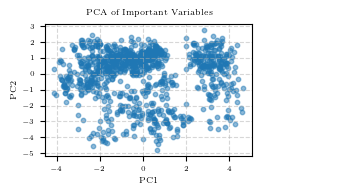

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df["nParamsFitNonDyn"] = df["nParamsFit"] - df["nParamsDynFit"]
df['ParamDynRatio'] = df['nParamsDynFit'] / df['nParamsFit']

# Select important variables for PCA
important_vars = [
    'nStates',
    'nTC', 'nDR',
    'nObsSets',
    'nParamsFitNonDyn', 'nParamsDynFit',
    'nDataPoints',
    'medErrorExp', 'medTime',
    'ratioIdentDyn', 'ratioNonDynIdent',
    'lowestLevelPopulation', 'exitflag_nan', 'exitflag_2'
]
print(len(important_vars), "variables selected for PCA.")


# Which vaiables should be log10 transformed before PCA?
vars_2log10 = [
    'nStates',
    'nTC', 'nDR',
    'nObsSets',
    'nParamsFitNonDyn', 'nParamsDynFit', 'nParamsFit',
    'nDataPoints',
    'medErrorExp', 'medTime'
]

# Drop rows with missing values in selected variables
df_pca = df[important_vars].dropna()

# Apply log10 transformation to selected variables (add a small constant to avoid log(0))
for var in vars_2log10:
    if var in df_pca.columns:
        df_pca[var] = np.log10(df_pca[var] + 1e-6)
df_pca = df_pca[important_vars].dropna()

print(f"PCA will be performed on {df_pca.shape[0]} samples with {df_pca.shape[1]} variables each.")
n_templates = df.loc[df_pca.index, "qTemplate"].sum()
n_synthetics = (df.loc[df_pca.index, "qTemplate"] == 0).sum()
print(f"Templates: {n_templates}, Synthetics: {n_synthetics}")

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_
print("Explained variance ratios by the first two principal components:", explained_var, sum(explained_var))
# Compute aspect ratio matching variance explained
pca_aspect_ratio = (explained_var[1] / explained_var[0]) ** 0.5


# Add PCA results to dataframe
df_pca['PC1'] = X_pca[:, 0]
df_pca['PC2'] = X_pca[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(single_width_mm*mm2in, 45*mm2in), width_ratios=[3, 1])

# Scatter plot of PCA results
ax[0].scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.5, s=10)
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[0].set_title("PCA of Important Variables")
ax[0].grid(True, linestyle="--", alpha=0.5)

ax[0].set_aspect(pca_aspect_ratio)


ax[1].axis("off")  # turn off the actual axis

plt.tight_layout()
plt.show()

14 variables selected for PCA.
PCA will be performed on 1012 samples with 14 variables each.
Templates: 19, Synthetics: 993
Explained variance ratios by the first two principal components: [0.32374176 0.17473649] 0.4984782509072899


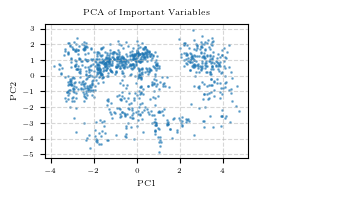

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df["nParamsFitNonDyn"] = df["nParamsFit"] - df["nParamsDynFit"]
df['ParamDynRatio'] = df['nParamsDynFit'] / df['nParamsFit']

# Select important variables for PCA
important_vars = [
    'nStates',
    'nTC', 'nDR',
    'nObsSets',
    'nParamsFit', 'nParamsDynFit',
    'nDataPoints',
    'medErrorExp', 'medTime',
    'ratioIdentDyn', 'ratioNonDynIdent',
    'lowestLevelPopulation', 'exitflag_nan', 'exitflag_2'
]
print(len(important_vars), "variables selected for PCA.")


# Which vaiables should be log10 transformed before PCA?
vars_2log10 = [
    'nStates',
    'nTC', 'nDR',
    'nObsSets',
    'nParamsFitNonDyn', 'nParamsDynFit', 'nParamsFit',
    'nDataPoints',
    'medErrorExp', 'medTime'
]

# Drop rows with missing values in selected variables
df_pca = df[important_vars].dropna()

# Apply log10 transformation to selected variables (add a small constant to avoid log(0))
for var in vars_2log10:
    if var in df_pca.columns:
        df_pca[var] = np.log10(df_pca[var] + 1e-6)
df_pca = df_pca[important_vars].dropna()

print(f"PCA will be performed on {df_pca.shape[0]} samples with {df_pca.shape[1]} variables each.")
n_templates = df.loc[df_pca.index, "qTemplate"].sum()
n_synthetics = (df.loc[df_pca.index, "qTemplate"] == 0).sum()
print(f"Templates: {n_templates}, Synthetics: {n_synthetics}")

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_
print("Explained variance ratios by the first two principal components:", explained_var, sum(explained_var))
# Compute aspect ratio matching variance explained
pca_aspect_ratio = (explained_var[1] / explained_var[0]) ** 0.5


# Add PCA results to dataframe
df_pca['PC1'] = X_pca[:, 0]
df_pca['PC2'] = X_pca[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(single_width_mm*mm2in, 45*mm2in), width_ratios=[3, 1])

# Scatter plot of PCA results
ax[0].scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.5, s=1)
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[0].set_title("PCA of Important Variables")
ax[0].grid(True, linestyle="--", alpha=0.5)

ax[0].set_aspect(pca_aspect_ratio)


ax[1].axis("off")  # turn off the actual axis

plt.tight_layout()
plt.show()

In [24]:
# Check template and synthetic inclusion in PCA for each template
print("Template Inclusion in PCA Analysis:")
print("=" * 60)
for template in templateNames:
    mask = df.loc[df_pca.index, "templateName"] == template
    is_template = (df.loc[df_pca.index, "qTemplate"] == 1) & mask
    is_synthetic = (df.loc[df_pca.index, "qTemplate"] == 0) & mask
    
    template_included = is_template.sum()
    synthetic_count = is_synthetic.sum()
    
    print(f"{template:20s}: Template={'Yes' if template_included > 0 else 'No ':3s}, "
          f"Synthetics={synthetic_count:3d}/50")

Template Inclusion in PCA Analysis:
Bachmann            : Template=Yes, Synthetics= 50/50
Becker              : Template=Yes, Synthetics= 48/50
Beer                : Template=Yes, Synthetics= 48/50
Boehm               : Template=Yes, Synthetics= 50/50
Borghans            : Template=Yes, Synthetics= 46/50
Brannmark           : Template=Yes, Synthetics= 50/50
Bruno               : Template=No , Synthetics= 50/50
Crauste             : Template=No , Synthetics= 25/50
Elowitz             : Template=Yes, Synthetics= 46/50
Fiedler             : Template=Yes, Synthetics= 48/50
Fujita              : Template=Yes, Synthetics= 40/50
Hass                : Template=No , Synthetics= 39/50
Isensee             : Template=Yes, Synthetics= 50/50
Lucarelli           : Template=Yes, Synthetics= 38/50
Merkle              : Template=Yes, Synthetics= 35/50
Raia                : Template=Yes, Synthetics= 49/50
Schwen              : Template=Yes, Synthetics= 50/50
Sneyd               : Template=Yes, Synthetics

<>:46: SyntaxWarning: invalid escape sequence '\%'
<>:47: SyntaxWarning: invalid escape sequence '\%'
<>:46: SyntaxWarning: invalid escape sequence '\%'
<>:47: SyntaxWarning: invalid escape sequence '\%'
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\3568280817.py:46: SyntaxWarning: invalid escape sequence '\%'
  ax[0].set_xlabel("PC1 ({:.1f}\%)".format(100 * explained_var[0]))
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\3568280817.py:47: SyntaxWarning: invalid escape sequence '\%'
  ax[0].set_ylabel("PC2 ({:.1f}\%)".format(100 * explained_var[1]))


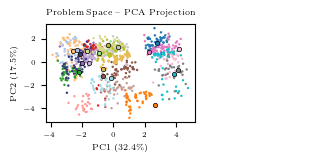

In [25]:
pca_lw = 0.5

fig, ax = plt.subplots(1, 2, figsize=(single_width_mm * mm2in, 40 * mm2in), width_ratios=[3, 1])

# Add dummy legend entries for "template" and "synthetic"
ax[0].scatter([], [], color="gray", marker="o", s=template_marker_size, edgecolor=template_edge_color, label="Template")

for idx, template in enumerate(templateNames):
    mask = df.loc[df_pca.index, "templateName"] == template
    is_template = (df.loc[df_pca.index, "qTemplate"] == 1) & mask
    is_synthetic = (df.loc[df_pca.index, "qTemplate"] == 0) & mask

    color = colorDict[template]
    marker = markerDict[template]

    # Elipse for synthetic points
    x = df_pca.loc[is_synthetic, 'PC1'].values
    y = df_pca.loc[is_synthetic, 'PC2'].values

    # scatter synthetic points
    ax[0].scatter(
        x, y,
        color=color, marker=marker,
        s=synthetic_marker_size, edgecolor='none',
        alpha=1,
        zorder=5
    )

    # plot corresponding template point and line to ellipse center
    if not is_template.any():
        continue  # skip if no template point available

    template_x = df_pca.loc[is_template, 'PC1'].values[0]
    template_y = df_pca.loc[is_template, 'PC2'].values[0]

    # template point
    ax[0].scatter(
        template_x, template_y,
        color=color, marker=marker,
        s=template_marker_size, edgecolor=template_edge_color,
        lw=pca_lw,
        zorder=10,
        alpha=1
    )

ax[0].set_xlabel("PC1 ({:.1f}\%)".format(100 * explained_var[0]))
ax[0].set_ylabel("PC2 ({:.1f}\%)".format(100 * explained_var[1]))
ax[0].set_title("Problem Space -- PCA Projection")
# ax[0].grid(True, linestyle="--", alpha=0.5)

ax[0].set_aspect(pca_aspect_ratio)

ax[0].set_yticks([-4, -2, 0, 2])
ax[0].set_xticks([-4, -2, 0, 2, 4])

# Custom legend: only show one entry per template
handles, labels_ = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
ax[1].axis("off")
# ax[1].legend(by_label.values(), by_label.keys(), loc="center", ncol=2)

plt.tight_layout()
plt.savefig("PCA_ProblemSpace_Scatter.png", dpi=600, bbox_inches='tight')
plt.savefig("PCA_ProblemSpace_Scatter.pdf", bbox_inches='tight')
plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\%'
<>:47: SyntaxWarning: invalid escape sequence '\%'
<>:46: SyntaxWarning: invalid escape sequence '\%'
<>:47: SyntaxWarning: invalid escape sequence '\%'
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\1558299364.py:46: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("PC1 ({:.1f}\%)".format(100 * explained_var[0]))
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\1558299364.py:47: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel("PC2 ({:.1f}\%)".format(100 * explained_var[1]))


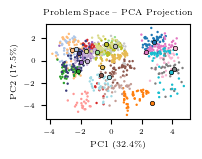

In [26]:
pca_lw = 0.5

fig, ax = plt.subplots(1, 1, figsize=(single_width_mm * mm2in, 40 * mm2in))

# Add dummy legend entries for "template" and "synthetic"
ax.scatter([], [], color="gray", marker="o", s=template_marker_size, edgecolor=template_edge_color, label="Template")

for idx, template in enumerate(templateNames):
    mask = df.loc[df_pca.index, "templateName"] == template
    is_template = (df.loc[df_pca.index, "qTemplate"] == 1) & mask
    is_synthetic = (df.loc[df_pca.index, "qTemplate"] == 0) & mask

    color = colorDict[template]
    marker = markerDict[template]

    # Elipse for synthetic points
    x = df_pca.loc[is_synthetic, 'PC1'].values
    y = df_pca.loc[is_synthetic, 'PC2'].values

    # scatter synthetic points
    ax.scatter(
        x, y,
        color=color, marker=marker,
        s=synthetic_marker_size, edgecolor='none',
        alpha=1,
        zorder=5
    )

    # plot corresponding template point and line to ellipse center
    if not is_template.any():
        continue  # skip if no template point available

    template_x = df_pca.loc[is_template, 'PC1'].values[0]
    template_y = df_pca.loc[is_template, 'PC2'].values[0]

    # template point
    ax.scatter(
        template_x, template_y,
        color=color, marker=marker,
        s=template_marker_size, edgecolor=template_edge_color,
        lw=pca_lw,
        zorder=10,
        alpha=1
    )

ax.set_xlabel("PC1 ({:.1f}\%)".format(100 * explained_var[0]))
ax.set_ylabel("PC2 ({:.1f}\%)".format(100 * explained_var[1]))
ax.set_title("Problem Space -- PCA Projection")
# ax[0].grid(True, linestyle="--", alpha=0.5)

ax.set_aspect(pca_aspect_ratio)

ax.set_yticks([-4, -2, 0, 2])
ax.set_xticks([-4, -2, 0, 2, 4])


plt.tight_layout()
plt.savefig("PCA_ProblemSpace_Scatter_V2.png", dpi=600, bbox_inches='tight')
plt.savefig("PCA_ProblemSpace_Scatter_V2.pdf", bbox_inches='tight')
plt.show()

In [27]:
from matplotlib.patches import Ellipse
import numpy as np

def calc_confidence_ellipse(x, y, conf=0.95):
    """Calculate parameters for a confidence ellipse for 2D data (x, y)."""
    if len(x) < 2 or len(y) < 2:
        return None
    cov = np.cov(x, y)
    if np.any(np.isnan(cov)) or np.any(np.isinf(cov)):
        return None

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    chi2_map = {0.68: 2.279, 0.95: 5.991, 0.99: 9.210}
    q = chi2_map.get(conf, 5.991)

    width, height = 2 * np.sqrt(vals * q)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    mean_x, mean_y = np.mean(x), np.mean(y)

    return (mean_x, mean_y), width, height, angle


def draw_confidence_ellipse(x, y, ax, conf=0.95, **kwargs):
    """Draw a confidence ellipse for 2D data (x, y) on the given axis."""
    params = calc_confidence_ellipse(x, y, conf)
    if params is None:
        return None
    (mean_x, mean_y), width, height, angle = params
    ell = Ellipse(xy=(mean_x, mean_y), width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)
    return ell

# def confidence_ellipse(x, y, ax, conf=0.95, **kwargs):
#     """Draw a confidence ellipse for 2D data (x, y) on the given axis."""
#     if len(x) < 2 or len(y) < 2:
#         return None, None
#     cov = np.cov(x, y)
#     if np.any(np.isnan(cov)) or np.any(np.isinf(cov)):
#         return None, None

#     vals, vecs = np.linalg.eigh(cov)
#     order = vals.argsort()[::-1]
#     vals, vecs = vals[order], vecs[:, order]

#     chi2_map = {0.68: 2.279, 0.95: 5.991, 0.99: 9.210}
#     q = chi2_map.get(conf, 5.991)

#     width, height = 2 * np.sqrt(vals * q)
#     angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
#     mean_x, mean_y = np.mean(x), np.mean(y)

#     # calculate area
#     area = np.pi * (width / 2) * (height / 2)

#     ell = Ellipse(xy=(mean_x, mean_y), width=width, height=height, angle=angle, **kwargs)
#     ax.add_patch(ell)
#     return ell, area


<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:58: SyntaxWarning: invalid escape sequence '\%'
<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:58: SyntaxWarning: invalid escape sequence '\%'
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\3101363587.py:57: SyntaxWarning: invalid escape sequence '\%'
  ax[0].set_xlabel("PC1 ({:.1f}\%)".format(100 * explained_var[0]))
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\3101363587.py:58: SyntaxWarning: invalid escape sequence '\%'
  ax[0].set_ylabel("PC2 ({:.1f}\%)".format(100 * explained_var[1]))


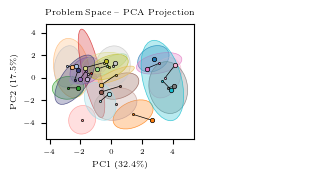

In [28]:
pca_lw = 0.5

fig, ax = plt.subplots(1, 2, figsize=(single_width_mm * mm2in, 45 * mm2in), width_ratios=[3, 1])

# Add dummy legend entries for "template" and "synthetic"
ax[0].scatter([], [], color="gray", marker="o", s=template_marker_size, edgecolor=template_edge_color, label="Template")

for idx, template in enumerate(templateNames):
    mask = df.loc[df_pca.index, "templateName"] == template
    is_template = (df.loc[df_pca.index, "qTemplate"] == 1) & mask
    is_synthetic = (df.loc[df_pca.index, "qTemplate"] == 0) & mask

    color = colorDict[template]
    marker = markerDict[template]

    # Elipse for synthetic points
    x = df_pca.loc[is_synthetic, 'PC1'].values
    y = df_pca.loc[is_synthetic, 'PC2'].values
    ell = draw_confidence_ellipse(
        x, y, ax[0], conf=0.95,
        edgecolor=color*np.array([1, 1, 1, 0.8]),
        facecolor=color*np.array([1, 1, 1, 0.3]),
        linewidth=pca_lw, linestyle='-'
        )

    # mark ellipse center
    ellipse_center_x = np.mean(x)
    ellipse_center_y = np.mean(y)
    ax[0].scatter(ellipse_center_x, ellipse_center_y,
                  color=color, marker='.', s=template_marker_size,
                  lw=pca_lw,
                  edgecolor='k',
                  zorder=5)

    # plot corresponding template point and line to ellipse center
    if not is_template.any():
        continue  # skip if no template point available

    template_x = df_pca.loc[is_template, 'PC1'].values[0]
    template_y = df_pca.loc[is_template, 'PC2'].values[0]

    # template point
    ax[0].scatter(
        template_x, template_y,
        color=color, marker=marker,
        s=template_marker_size, edgecolor=template_edge_color,
        lw=pca_lw,
        zorder=10,
        alpha=1
    )
    # line from ellipse center to template point
    ax[0].plot([ellipse_center_x, template_x],
               [ellipse_center_y, template_y],
               color='k', linestyle='-', linewidth=pca_lw, alpha=1, zorder=4)


ax[0].set_xlabel("PC1 ({:.1f}\%)".format(100 * explained_var[0]))
ax[0].set_ylabel("PC2 ({:.1f}\%)".format(100 * explained_var[1]))
ax[0].set_title("Problem Space -- PCA Projection")
# ax[0].grid(True, linestyle="--", alpha=0.5)

ax[0].set_aspect(pca_aspect_ratio)

# Custom legend: only show one entry per template
handles, labels_ = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
ax[1].axis("off")
# ax[1].legend(by_label.values(), by_label.keys(), loc="center", ncol=2)

plt.tight_layout()
plt.savefig("PCA_ProblemSpace_Ellipses.png", dpi=600, bbox_inches='tight')
plt.savefig("PCA_ProblemSpace_Ellipses.pdf", bbox_inches='tight')
plt.show()

In [29]:
## Calculate size of confidence ellipses to determine zordering
for idx, template in enumerate(templateNames):
    mask = df.loc[df_pca.index, "templateName"] == template
    is_template = (df.loc[df_pca.index, "qTemplate"] == 1) & mask
    is_synthetic = (df.loc[df_pca.index, "qTemplate"] == 0) & mask

    color = colorDict[template]
    marker = markerDict[template]

    # Elipse for synthetic points
    x = df_pca.loc[is_synthetic, 'PC1'].values
    y = df_pca.loc[is_synthetic, 'PC2'].values
    ell_params = calc_confidence_ellipse(
        x, y, conf=0.95
        )
    if ell_params is None:
        ellipse_area = np.inf  # assign large area if ellipse cannot be computed
    else:
        (mean_x, mean_y), width, height, angle = ell_params
        ellipse_area = np.pi * (width / 2) * (height / 2)
    df.loc[df_pca.index, f'ellipse_area_{template}'] = ellipse_area

# Sort templates by ellipse area for z-ordering (smaller area = plotted on top)
template_areas = []
for template in templateNames:
    area = df.loc[df_pca.index, f'ellipse_area_{template}'].values[0]
    template_areas.append((template, area))
template_areas.sort(key=lambda x: x[1])  # sort by area
area_sorted_templates = [t[0] for t in template_areas]

<>:62: SyntaxWarning: invalid escape sequence '\%'
<>:63: SyntaxWarning: invalid escape sequence '\%'
<>:62: SyntaxWarning: invalid escape sequence '\%'
<>:63: SyntaxWarning: invalid escape sequence '\%'
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\1607374222.py:62: SyntaxWarning: invalid escape sequence '\%'
  ax[0].set_xlabel("PC1 ({:.1f}\%)".format(100 * explained_var[0]))
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\1607374222.py:63: SyntaxWarning: invalid escape sequence '\%'
  ax[0].set_ylabel("PC2 ({:.1f}\%)".format(100 * explained_var[1]))


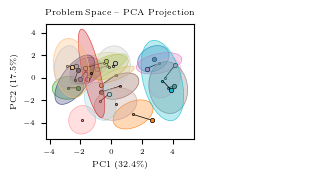

In [30]:
pca_lw = 0.5

fig, ax = plt.subplots(1, 2, figsize=(single_width_mm * mm2in, 45 * mm2in), width_ratios=[3, 1])


for idx, template in enumerate(area_sorted_templates):
    mask = df.loc[df_pca.index, "templateName"] == template
    is_template = (df.loc[df_pca.index, "qTemplate"] == 1) & mask
    is_synthetic = (df.loc[df_pca.index, "qTemplate"] == 0) & mask

    color = colorDict[template]
    marker = markerDict[template]

    # zorders
    z_ellipse = idx
    z_center = idx + 0.2
    z_line = idx + 0.1
    z_template = idx + 0.3

    # Elipse for synthetic points
    x = df_pca.loc[is_synthetic, 'PC1'].values
    y = df_pca.loc[is_synthetic, 'PC2'].values
    draw_confidence_ellipse(
        x, y, ax[0], conf=0.95,
        zorder=z_ellipse,
        edgecolor=color*np.array([1, 1, 1, 0.8]),
        facecolor=color*np.array([1, 1, 1, 0.3]),
        linewidth=pca_lw, linestyle='-'
        )

    # mark ellipse center
    ellipse_center_x = np.mean(x)
    ellipse_center_y = np.mean(y)
    ax[0].scatter(ellipse_center_x, ellipse_center_y,
                  color=color, marker='.', s=template_marker_size,
                  lw=pca_lw,
                  edgecolor='k',
                  zorder=z_center)

    # plot corresponding template point and line to ellipse center
    if not is_template.any():
        continue  # skip if no template point available

    template_x = df_pca.loc[is_template, 'PC1'].values[0]
    template_y = df_pca.loc[is_template, 'PC2'].values[0]

    # template point
    ax[0].scatter(
        template_x, template_y,
        color=color, marker=marker,
        s=template_marker_size, edgecolor=template_edge_color,
        lw=pca_lw,
        zorder=z_template,
        alpha=1
    )
    # line from ellipse center to template point
    ax[0].plot([ellipse_center_x, template_x],
               [ellipse_center_y, template_y],
               color='k', linestyle='-', linewidth=pca_lw, alpha=1, zorder=z_line)


ax[0].set_xlabel("PC1 ({:.1f}\%)".format(100 * explained_var[0]))
ax[0].set_ylabel("PC2 ({:.1f}\%)".format(100 * explained_var[1]))
ax[0].set_title("Problem Space -- PCA Projection")
# ax[0].grid(True, linestyle="--", alpha=0.5)

ax[0].set_aspect(pca_aspect_ratio)

# Custom legend: only show one entry per template
handles, labels_ = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
ax[1].axis("off")
# ax[1].legend(by_label.values(), by_label.keys(), loc="center", ncol=2)

plt.tight_layout()
plt.savefig("PCA_ProblemSpace_Ellipses_zordered.png", dpi=600, bbox_inches='tight')
plt.savefig("PCA_ProblemSpace_Ellipses_zordered.pdf", bbox_inches='tight')
plt.show()

<>:62: SyntaxWarning: invalid escape sequence '\%'
<>:63: SyntaxWarning: invalid escape sequence '\%'
<>:62: SyntaxWarning: invalid escape sequence '\%'
<>:63: SyntaxWarning: invalid escape sequence '\%'
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\3358390134.py:62: SyntaxWarning: invalid escape sequence '\%'
  ax[0].set_xlabel("PC1 ({:.1f}\%)".format(100 * explained_var[0]))
C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\3358390134.py:63: SyntaxWarning: invalid escape sequence '\%'
  ax[0].set_ylabel("PC2 ({:.1f}\%)".format(100 * explained_var[1]))


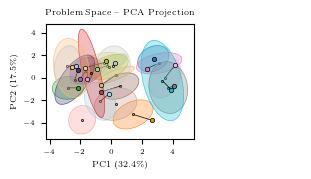

In [31]:
pca_lw = 0.5

fig, ax = plt.subplots(1, 2, figsize=(single_width_mm * mm2in, 45 * mm2in), width_ratios=[3, 1])


for idx, template in enumerate(area_sorted_templates):
    mask = df.loc[df_pca.index, "templateName"] == template
    is_template = (df.loc[df_pca.index, "qTemplate"] == 1) & mask
    is_synthetic = (df.loc[df_pca.index, "qTemplate"] == 0) & mask

    color = colorDict[template]
    marker = markerDict[template]

    # zorders
    z_ellipse = idx
    z_center = idx + 0.2
    z_line = idx + 0.1
    z_template = 25

    # Elipse for synthetic points
    x = df_pca.loc[is_synthetic, 'PC1'].values
    y = df_pca.loc[is_synthetic, 'PC2'].values
    draw_confidence_ellipse(
        x, y, ax[0], conf=0.95,
        zorder=z_ellipse,
        edgecolor=color*np.array([1, 1, 1, 0.8]),
        facecolor=color*np.array([1, 1, 1, 0.3]),
        linewidth=pca_lw, linestyle='-'
        )

    # mark ellipse center
    ellipse_center_x = np.mean(x)
    ellipse_center_y = np.mean(y)
    ax[0].scatter(ellipse_center_x, ellipse_center_y,
                  color=color, marker='.', s=template_marker_size,
                  lw=pca_lw,
                  edgecolor='k',
                  zorder=z_center)

    # plot corresponding template point and line to ellipse center
    if not is_template.any():
        continue  # skip if no template point available

    template_x = df_pca.loc[is_template, 'PC1'].values[0]
    template_y = df_pca.loc[is_template, 'PC2'].values[0]

    # template point
    ax[0].scatter(
        template_x, template_y,
        color=color, marker=marker,
        s=template_marker_size, edgecolor=template_edge_color,
        lw=pca_lw,
        zorder=z_template,
        alpha=1
    )
    # line from ellipse center to template point
    ax[0].plot([ellipse_center_x, template_x],
               [ellipse_center_y, template_y],
               color='k', linestyle='-', linewidth=pca_lw, alpha=1, zorder=z_line)


ax[0].set_xlabel("PC1 ({:.1f}\%)".format(100 * explained_var[0]))
ax[0].set_ylabel("PC2 ({:.1f}\%)".format(100 * explained_var[1]))
ax[0].set_title("Problem Space -- PCA Projection")
# ax[0].grid(True, linestyle="--", alpha=0.5)

ax[0].set_aspect(pca_aspect_ratio)

# Custom legend: only show one entry per template
handles, labels_ = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
ax[1].axis("off")
# ax[1].legend(by_label.values(), by_label.keys(), loc="center", ncol=2)

plt.tight_layout()
plt.savefig("PCA_ProblemSpace_Ellipses_zordered2.png", dpi=600, bbox_inches='tight')
plt.savefig("PCA_ProblemSpace_Ellipses_zordered2.pdf", bbox_inches='tight')
plt.show()

## Legend Snippets

### Template Names

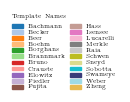

In [32]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(1, 1))
ax.axis("off")

# Create legend handles for each template name and color
handles = [
    mpatches.Patch(color=colorDict[t], label=t)
    for t in templateNames
]

# Add legend to the figure
legend = ax.legend(handles=handles,
                   title="Template Names",
                   ncol=2,
                   frameon=False,
                   title_fontsize=4,
                   fontsize=4,
                   alignment="left",
                   columnspacing=1,
                   labelspacing=0.2
                   )

legend._legend_box.sep = 3

# Adjust figure size
fig.canvas.draw()
bbox = legend.get_window_extent()
width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
fig.set_size_inches(width, height)

plt.tight_layout(pad=0, h_pad=0, w_pad=0)
plt.savefig("PCA_ProblemSpace_Legend_Templates.png", dpi=600, bbox_inches='tight', transparent=True)
plt.savefig("PCA_ProblemSpace_Legend_Templates.pdf", dpi=600, bbox_inches='tight', transparent=True)

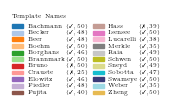

In [33]:
import matplotlib.patches as mpatches
plt.rcParams["text.latex.preamble"] = r"\usepackage{calc}\usepackage{pifont}"


fig, ax = plt.subplots(figsize=(1, 1))
ax.axis("off")

# Create legend handles for each template name and color
handles = [
    mpatches.Patch(color=colorDict[t], label=t)
    for t in templateNames
]

# Modify handles to include counts of included synthetics for each template
handles = []
for (id, t) in enumerate(templateNames):
    mask = df.loc[df_pca.index, "templateName"] == t

    is_template = (df.loc[df_pca.index, "qTemplate"] == 1) & mask
    is_synthetic = (df.loc[df_pca.index, "qTemplate"] == 0) & mask
    
    template_included = is_template.sum()
    synthetic_count = is_synthetic.sum()

    # label = (
    #     f"{t:<20s}"
    #     f"({'\\ding{51}' if template_included > 0 else '\\ding{55}'}, "
    #     f"{synthetic_count})"
    # )
    longest_name = "Brannmark" if id <= 10 else "Swameye"
    ding_ref = r"\ding{51}"

    mark = r"\ding{51}" if template_included > 0 else r"\ding{55}"

    label = (
        rf"\makebox[\widthof{{{longest_name}}}][l]{{{t}}}"
        rf"\,(\makebox[\widthof{{\ding{{51}}}}][c]{{{mark}}},\,{synthetic_count})"
    )

    
    handles.append(mpatches.Patch(color=colorDict[t], label=label))



# Add legend to the figure
legend = ax.legend(handles=handles,
                   title="Template Names",
                   ncol=2,
                   frameon=False,
                   title_fontsize=4,
                   fontsize=4,
                   alignment="left",
                   columnspacing=1,
                   labelspacing=0.2
                   )




legend._legend_box.sep = 3

# Adjust figure size
fig.canvas.draw()
bbox = legend.get_window_extent()
width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
fig.set_size_inches(width, height)

plt.tight_layout(pad=0, h_pad=0, w_pad=0)
plt.savefig("PCA_ProblemSpace_Legend_Templates_Numbers.png", dpi=600, bbox_inches='tight', transparent=True)
plt.savefig("PCA_ProblemSpace_Legend_Templates_Numbers.pdf", dpi=600, bbox_inches='tight', transparent=True)

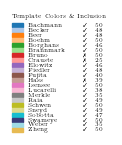

In [34]:
import matplotlib.patches as mpatches
plt.rcParams["text.latex.preamble"] = r"\usepackage{calc}\usepackage{pifont}"


fig, ax = plt.subplots(figsize=(1, 1))
ax.axis("off")

# Create legend handles with counts of included synthetics for each template
handles = []
for (id, t) in enumerate(templateNames):
    mask = df.loc[df_pca.index, "templateName"] == t

    is_template = (df.loc[df_pca.index, "qTemplate"] == 1) & mask
    is_synthetic = (df.loc[df_pca.index, "qTemplate"] == 0) & mask
    
    template_included = is_template.sum()
    synthetic_count = is_synthetic.sum()

    # label = (
    #     f"{t:<20s}"
    #     f"({'\\ding{51}' if template_included > 0 else '\\ding{55}'}, "
    #     f"{synthetic_count})"
    # )
    longest_name = "Brannmark"
    ding_ref = r"\ding{51}"
    spacer=r"\hspace{2mm}"

    mark = r"\ding{51}" if template_included > 0 else r"\ding{55}"

    label = (
        rf"\makebox[\widthof{{{longest_name}}}][l]{{{t}}}"
        rf"\hspace{{4.5mm}}\makebox[\widthof{{\ding{{51}}}}][c]{{{mark}}}{spacer}{synthetic_count}"
    )

    
    handles.append(mpatches.Patch(color=colorDict[t], label=label))



# Add legend to the figure
legend = ax.legend(handles=handles,
                   title=r"Template Colors \& Inclusion",
                   ncol=1,
                   frameon=False,
                   title_fontsize=4,
                   fontsize=4,
                   alignment="left",
                   columnspacing=1,
                   labelspacing=0.
                   )




legend._legend_box.sep = 3

# Adjust figure size
fig.canvas.draw()
bbox = legend.get_window_extent()
width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
fig.set_size_inches(width, height)

plt.tight_layout(pad=0, h_pad=0, w_pad=0)
plt.savefig("PCA_ProblemSpace_Legend_Templates_Numbers_V2.png", dpi=600, bbox_inches='tight', transparent=True)
plt.savefig("PCA_ProblemSpace_Legend_Templates_Numbers_V2.pdf", dpi=600, bbox_inches='tight', transparent=True)

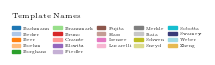

In [35]:
fig, ax = plt.subplots(figsize=(1, 0.5))
ax.axis("off")

# Create legend handles for each template name and color
handles = [
    mpatches.Patch(color=colorDict[t], label=t)
    for t in templateNames
]

# Add legend to the figure
legend = ax.legend(handles=handles,
                   title="Template Names",
                   ncol=5,
                   frameon=False,
                   title_fontsize=5,
                   fontsize=3,
                   alignment="left",
                   columnspacing=1,
                   # labelspacing=0.4
                   )

legend._legend_box.sep = 5

# Adjust figure size
fig.canvas.draw()
bbox = legend.get_window_extent()
width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
fig.set_size_inches(width, height)

plt.tight_layout(pad=0, h_pad=0, w_pad=0)
plt.savefig("PCA_ProblemSpace_Legend_Templates_V2.png", dpi=600, bbox_inches='tight', transparent=True)
plt.savefig("PCA_ProblemSpace_Legend_Templates_V2.pdf", dpi=600, bbox_inches='tight', transparent=True)

C:\Users\neubrand\AppData\Local\Temp\ipykernel_14952\1934511804.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


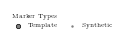

In [36]:
fig, ax = plt.subplots(figsize=(1, 0.5))
ax.axis("off")

# Create dummy legend handles for template and synthetic
template_handle = plt.Line2D([], [], color="gray", marker="o", linestyle="None",
                             markeredgewidth=template_lw,
                            markersize=np.sqrt(template_marker_size), markeredgecolor=template_edge_color, label="Template")
synthetic_handle = plt.Line2D([], [], color="gray", marker="o", linestyle="None",
                              markersize=np.sqrt(synthetic_marker_size), markeredgecolor="none", label="Synthetic")

handles = [template_handle, synthetic_handle]

legend = ax.legend(handles=handles,
                   title="Marker Types",
                   ncol=2,
                   title_fontsize=4,
                   fontsize=4,
                   frameon=False,
                   alignment="left",
                   columnspacing=1.5,
                   labelspacing=0.2
                   )

legend._legend_box.sep = 3

# Adjust figure size
fig.canvas.draw()
bbox = legend.get_window_extent()
width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
fig.set_size_inches(width, height)


plt.tight_layout()
plt.savefig("PCA_ProblemSpace_Legend_Markers.png", dpi=600, bbox_inches='tight', transparent=True)
plt.savefig("PCA_ProblemSpace_Legend_Markers.pdf", dpi=600, bbox_inches='tight', transparent=True)

#### Summary Stats

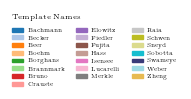

In [37]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(1, 1))
ax.axis("off")

# Create legend handles for each template name and color
handles = [
    mpatches.Patch(color=colorDict[t], label=t)
    for t in templateNames
]

# Add legend to the figure
legend = ax.legend(handles=handles,
                   title="Template Names",
                   ncol=3,
                   frameon=False,
                   title_fontsize=5,
                   fontsize=4,
                   alignment="left"
                   )

legend._legend_box.sep = 5

# Adjust figure size
fig.canvas.draw()
bbox = legend.get_window_extent()
width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
fig.set_size_inches(width, height)

plt.tight_layout()
plt.savefig("Summary_Stats_Legend_Templates.png", dpi=600, bbox_inches='tight', transparent=True)
plt.savefig("Summary_Stats_Legend_Templates.pdf", dpi=600, bbox_inches='tight', transparent=True)

NameError: name 'HandlerTuple' is not defined

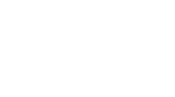

In [38]:
fig, ax = plt.subplots(figsize=(2, 1))
ax.axis("off")

# Create dummy legend handles for template and synthetic markers
template_handle = plt.Line2D([], [], color="gray", marker="o", linestyle="None",
                             markeredgewidth=template_lw,
                             markersize=np.sqrt(template_marker_size), markeredgecolor=template_edge_color, label="Template")

handles = [template_handle] #, synthetic_handle, synthetic_handle_pooled]
legend = ax.legend(handles=handles,
                   handler_map={tuple: HandlerTuple(ndivide=None)},
                   labels=["Templates"],
                   title="Marker Types",
                   loc="center",
                   ncol=1,
                   title_fontsize=5,
                   fontsize=4,
                   frameon=False,
                   alignment="left",
                   handletextpad=2
                   )

legend._legend_box.sep = 5

# Adjust figure size
fig.canvas.draw()
bbox = legend.get_window_extent()
width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
fig.set_size_inches(width, height)


plt.tight_layout()
plt.savefig("SummaryStats_Legend_Markers.png", dpi=600, bbox_inches='tight')
plt.savefig("SummaryStats_Legend_Markers.pdf", dpi=600, bbox_inches='tight')

C:\Users\neubrand\AppData\Local\Temp\ipykernel_22848\913945717.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=0, w_pad=0, h_pad=0)


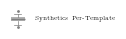

In [ ]:
# fig, ax = plt.subplots(figsize=(0.2, 0.38))
fig, ax = plt.subplots(figsize=(0.2, 0.25))
ax.axis("off")

# Example data for boxplot
data = np.concatenate([np.zeros(30), np.ones(20), 3* np.ones(20), -3*np.ones(20), -1 * np.ones(20), [ -4.1, 4.1 ]])

# Draw gray boxplot

dummy_color = 'gray'
bp = ax.boxplot(
            data,
            # positions=[1],
            widths=bp_width,  # relative box width (adjust as needed)
            patch_artist=True,
            boxprops=dict(facecolor=dummy_color, alpha=0.6, color='none'),
            whiskerprops=dict(color=dummy_color, alpha=1, lw=0.5),
            capprops=dict(color=dummy_color, alpha=1, lw=0.5),
            medianprops=dict(color=dummy_color, lw=1),
            flierprops=dict(marker='.',
                            markerfacecolor=dummy_color,
                            markeredgecolor=dummy_color,
                            alpha=1, markersize=2
                            )
)

ax.set_ylim(-5, 5)

ax.annotate("Synthetics Per-Template", xy=(1.6, 0.5), xycoords="axes fraction",
            ha="left", va="center", fontsize=4, color="black")

ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
plt.savefig("gray_boxplot_snippet.png", dpi=300, bbox_inches='tight', transparent=True)
plt.savefig("gray_boxplot_snippet.pdf", dpi=300, bbox_inches='tight', transparent=True)

C:\Users\neubrand\AppData\Local\Temp\ipykernel_22848\3092264597.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=0, w_pad=0, h_pad=0)


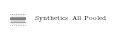

In [ ]:
# fig, ax = plt.subplots(figsize=(0.2, 0.38))
fig, ax = plt.subplots(figsize=(0.2, 0.25))
ax.axis("off")

# Example data for boxplot
data = np.concatenate([np.zeros(30), np.ones(20), 3* np.ones(20), -3*np.ones(20), -1 * np.ones(20), [ -4.1, 4.1 ]])
bp_stats_data = boxplot_stats(data)

bp_stats_data = {'median': 0.0,
 'q1': -1.0,
 'q3': 1.0,
 'iqr': 2.0,
 'lower_whisker': -2.0,
 'upper_whisker': 2.0,
 'fliers': np.array([-4.1,  4.1]),
 'min': -4.1,
 'max': 4.1}


# Draw gray boxplot

synth_color = "gray"
synth_color_fill = "lightgray"

quartile_alpha = 0.8
quartile_lw = 0.5
whisker_alpha = 0.3
whisker_lw = 0.5
whisker_ls = ':'


ax.axhline(bp_stats_data['median'],
                color=synth_color,
                linestyle='-', lw=1.5,
                zorder=-4)
ax.axhline(bp_stats_data['q1'], color=synth_color, linestyle='-', lw=quartile_lw, zorder=-5)
ax.axhline(bp_stats_data['q3'], color=synth_color, linestyle='-', lw=quartile_lw, zorder=-5)
ax.axhline(bp_stats_data['lower_whisker'], color=synth_color, linestyle=whisker_ls, lw=whisker_lw, zorder=-5)
ax.axhline(bp_stats_data['upper_whisker'], color=synth_color, linestyle=whisker_ls, lw=whisker_lw, zorder=-5)
ax.fill_between([lims[var][0], lims[var][1]],
                bp_stats_data['q1'], bp_stats_data['q3'],
                color=synth_color_fill, alpha=quartile_alpha,
                lw=0,
                zorder=-6)
ax.fill_between([lims[var][0], lims[var][1]],
                bp_stats_data['lower_whisker'], bp_stats_data['upper_whisker'],
                color=synth_color_fill, alpha=whisker_alpha,
                lw=0,
                zorder=-6)

ax.set_ylim(-3.5, 3.5)

ax.annotate("Synthetics All Pooled", xy=(1.6, 0.5), xycoords="axes fraction",
            ha="left", va="center", fontsize=4, color="black")

ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
plt.savefig("gray_background_snippet.png", dpi=300, bbox_inches='tight', transparent=True)
plt.savefig("gray_background_snippet.pdf", dpi=300, bbox_inches='tight', transparent=True)

#### Summary Stats V2